In [126]:
import pandas as pd

In [127]:
df=pd.read_csv('medical_insurance.csv')

In [128]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [129]:
df.shape

(2772, 7)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [131]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [132]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [133]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [134]:
import matplotlib.pyplot as plt

In [135]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

Text(0.5, 1.0, 'distribution of charges')

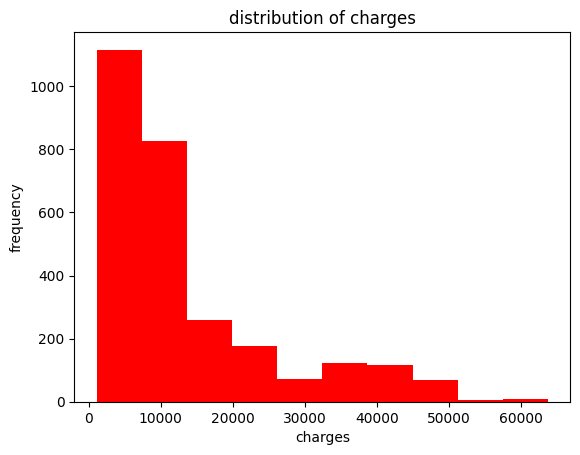

In [136]:
plt.hist(df['charges'],bins=10,color='red')
plt.xlabel('charges')
plt.ylabel('frequency')
plt.title('distribution of charges')

<function matplotlib.pyplot.show(close=None, block=None)>

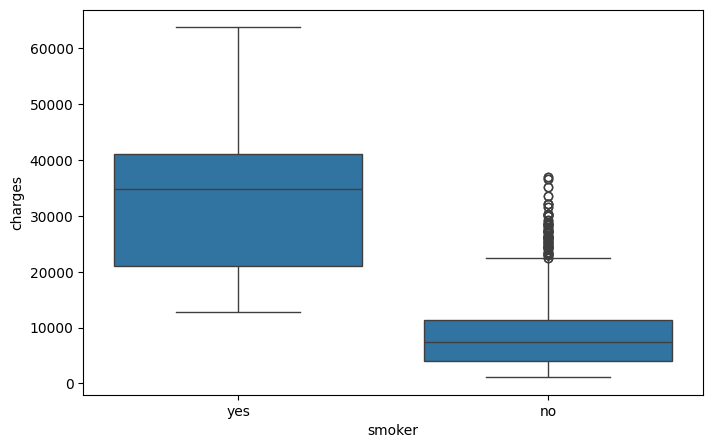

In [137]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='smoker',y='charges')
plt.show

In [138]:
print(df[['age', 'bmi', 'children', 'charges']].corr())

               age       bmi  children   charges
age       1.000000  0.113048  0.037574  0.298624
bmi       0.113048  1.000000 -0.001492  0.199846
children  0.037574 -0.001492  1.000000  0.066442
charges   0.298624  0.199846  0.066442  1.000000


In [139]:
df.duplicated().sum()
print(f"Percentage: {df.duplicated().sum() / df.shape[0] * 100:.2f}%")

Percentage: 51.77%


In [140]:
df = df.drop_duplicates()

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
df.shape

(1337, 7)

In [143]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [144]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [145]:
print(df[['age', 'bmi', 'children', 'charges']].corr())

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

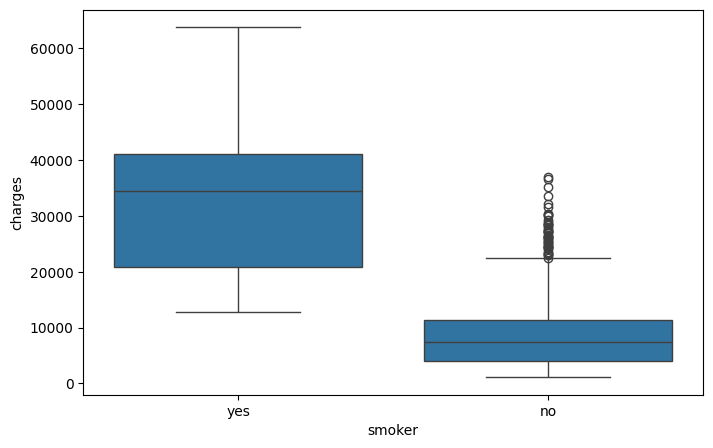

In [146]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='smoker',y='charges')
plt.show

In [147]:
df.groupby('smoker')['charges'].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

In [148]:
df.groupby('smoker')['charges'].median()

smoker
no      7345.72660
yes    34456.34845
Name: charges, dtype: float64

In [149]:
df['smoker'].value_counts()


smoker
no     1063
yes     274
Name: count, dtype: int64

In [150]:
print(df['smoker'].unique())
print(df['sex'].unique())

['yes' 'no']
['female' 'male']


In [151]:
df['sex']=df['sex'].map({'female':0,'male':1})
df['smoker']=df['smoker'].map({'no':0,'yes':1})
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)



In [152]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [153]:
df.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

In [91]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1337, 9)
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object
age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   int64  
 7   region_southeast  1337 non-null   int64  
 8   region_southwest  1337 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 104.5 KB


In [93]:
df.isnull().sum()
df.notnull().sum()

age                 1337
sex                 1337
bmi                 1337
children            1337
smoker              1337
charges             1337
region_northwest    1337
region_southeast    1337
region_southwest    1337
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

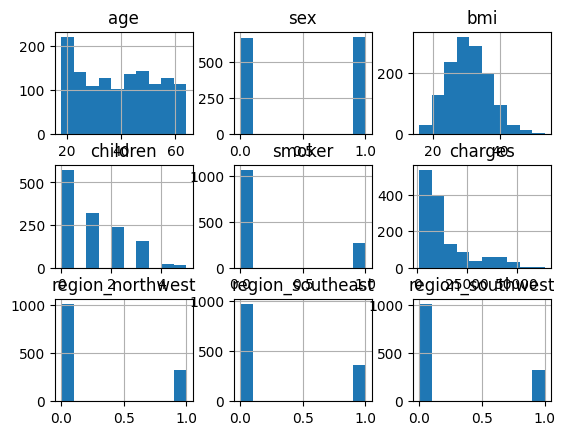

In [94]:
import matplotlib.pyplot as plt
df.hist()
plt.show

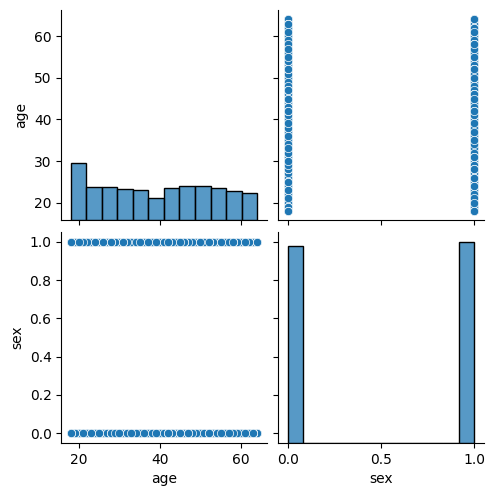

In [95]:
import seaborn as sns
sns.pairplot(df[['age','sex']])
plt.show()

In [96]:
df.describe()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487,0.242334,0.272251,0.243082
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656,0.428655,0.445285,0.429104
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900,0.000000,0.000000,0.000000
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000,0.000000,0.000000,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300,0.000000,0.000000,0.000000
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450,0.000000,1.000000,0.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010,1.000000,1.000000,1.000000


In [97]:
df['charges'].mean()

np.float64(13279.121486655948)

In [98]:
df['charges'].median()

np.float64(9386.1613)

(array([207., 174., 154., 140., 139., 119.,  55.,  32.,  42.,  36.,  23.,
         27.,  16.,  16.,   3.,  15.,  22.,  22.,  22.,  19.,  16.,  14.,
         16.,   2.,   1.,   1.,   0.,   1.,   1.,   2.]),
 array([ 1121.8739  ,  3210.159037,  5298.444174,  7386.729311,
         9475.014448, 11563.299585, 13651.584722, 15739.869859,
        17828.154996, 19916.440133, 22004.72527 , 24093.010407,
        26181.295544, 28269.580681, 30357.865818, 32446.150955,
        34534.436092, 36622.721229, 38711.006366, 40799.291503,
        42887.57664 , 44975.861777, 47064.146914, 49152.432051,
        51240.717188, 53329.002325, 55417.287462, 57505.572599,
        59593.857736, 61682.142873, 63770.42801 ]),
 <BarContainer object of 30 artists>)

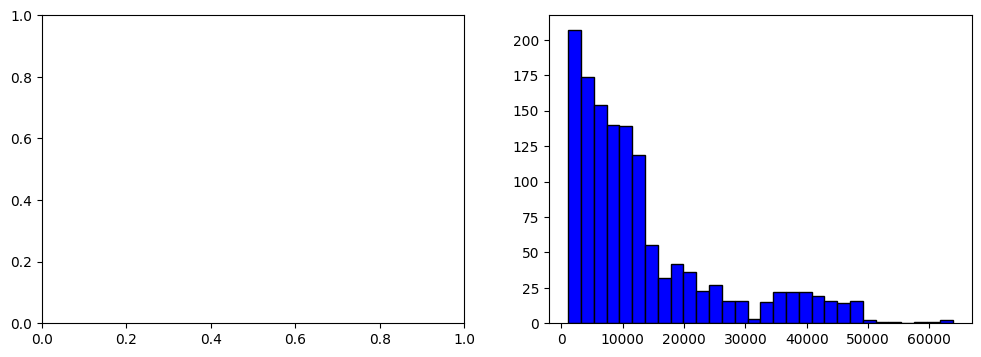

In [99]:
import numpy as np
df['log_charges']=np.log(df['charges'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.hist(df['charges'],bins=30,color='blue',edgecolor='black')


(array([ 19.,   1.,  25.,  37.,  32.,  36.,  33.,  32.,  36.,  38.,  67.,
         50.,  58.,  71.,  69.,  85.,  86., 112.,  86.,  28.,  42.,  49.,
         40.,  34.,  17.,  44.,  54.,  45.,   7.,   4.]),
 array([ 7.02275569,  7.157432  ,  7.2921083 ,  7.42678461,  7.56146091,
         7.69613722,  7.83081352,  7.96548983,  8.10016613,  8.23484244,
         8.36951874,  8.50419505,  8.63887136,  8.77354766,  8.90822397,
         9.04290027,  9.17757658,  9.31225288,  9.44692919,  9.58160549,
         9.7162818 ,  9.8509581 ,  9.98563441, 10.12031071, 10.25498702,
        10.38966332, 10.52433963, 10.65901594, 10.79369224, 10.92836855,
        11.06304485]),
 <BarContainer object of 30 artists>)

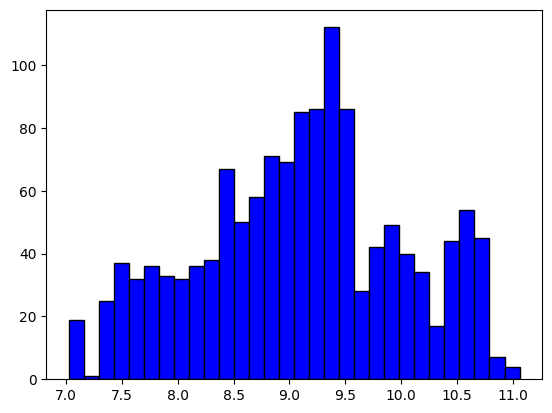

In [100]:
plt.hist(df['log_charges'],bins=30,color='blue',edgecolor='black')

In [101]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,log_charges
0,19,0,27.900,0,1,16884.92400,0,0,1,9.734176
1,18,1,33.770,1,0,1725.55230,0,1,0,7.453302
2,28,1,33.000,3,0,4449.46200,0,1,0,8.400538
3,33,1,22.705,0,0,21984.47061,1,0,0,9.998092
4,32,1,28.880,0,0,3866.85520,1,0,0,8.260197


In [102]:
from sklearn.linear_model import LinearRegression

In [124]:
X=df.drop(columns=['charges','log_charges'])
y=df['log_charges']

In [104]:
from sklearn.model_selection import train_test_split

In [105]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [106]:
Ir=LinearRegression()

In [107]:
Ir.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [108]:
y_Ir_predict=Ir.predict(X_test)

In [109]:
from sklearn.ensemble import RandomForestRegressor

In [110]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [111]:
from sklearn.metrics import r2_score ,mean_squared_error
import numpy as np
rmSE_log=np.sqrt(mean_squared_error(y_test,y_Ir_predict))
r2score_log=r2_score(y_test,y_Ir_predict)
print(rmSE_log)
print(r2score_log)

0.39785404297544835
0.8294642959644736


In [112]:
rmSE_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2score_rf=r2_score(y_test,y_pred_rf)
print(rmSE_rf)
print(r2score_rf)

0.37172836121114883
0.8511258958114565


In [113]:
pred_ir_dollar=np.exp(y_Ir_predict)
pred_rf_dollar=np.exp(y_pred_rf)
actual_dollar=np.exp(y_test)

In [114]:
rmSE_actual=np.sqrt(mean_squared_error(actual_dollar,pred_ir_dollar))
r2score_actual=r2_score(actual_dollar,pred_ir_dollar)
print(rmSE_actual)
print(r2score_actual)

7197.965301777498
0.7180462873105252


In [115]:
rmSE_rf_actual=np.sqrt(mean_squared_error(actual_dollar,pred_rf_dollar))
r2score_rf_actual=r2_score(actual_dollar,pred_rf_dollar)
print(rmSE_rf_actual)
print(r2score_rf_actual)

4375.882925100448
0.8957947239776376


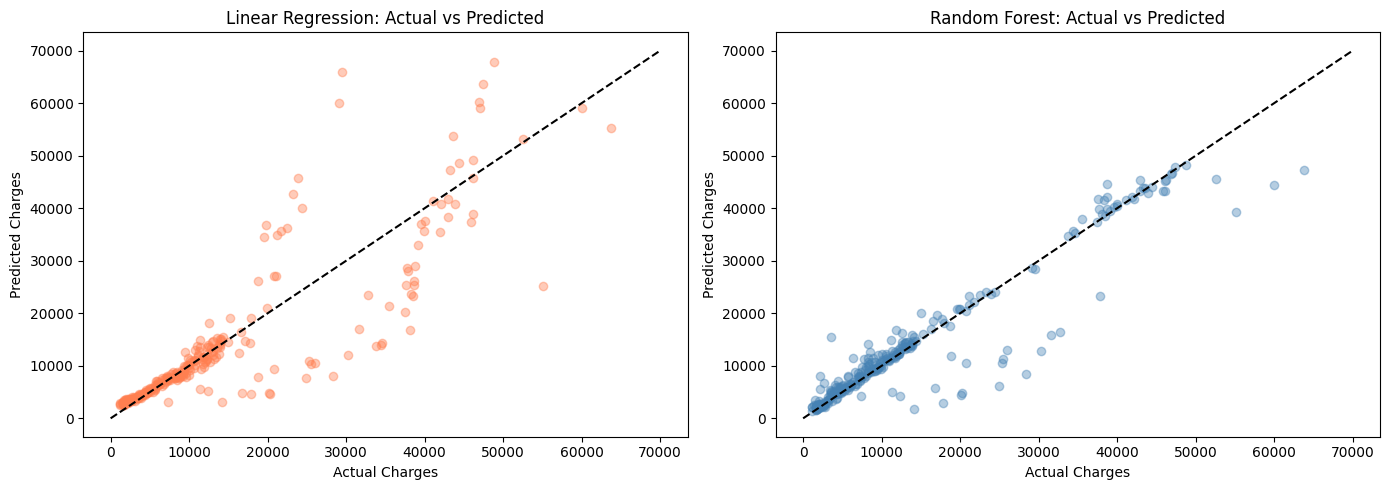

In [154]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(actual_dollar, pred_ir_dollar, alpha=0.4, color='coral')
axes[0].plot([0, 70000], [0, 70000], 'k--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')

# Random Forest
axes[1].scatter(actual_dollar, pred_rf_dollar, alpha=0.4, color='steelblue')
axes[1].plot([0, 70000], [0, 70000], 'k--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Charges')
axes[1].set_ylabel('Predicted Charges')

plt.tight_layout()
plt.show()

In [117]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_

In [118]:
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

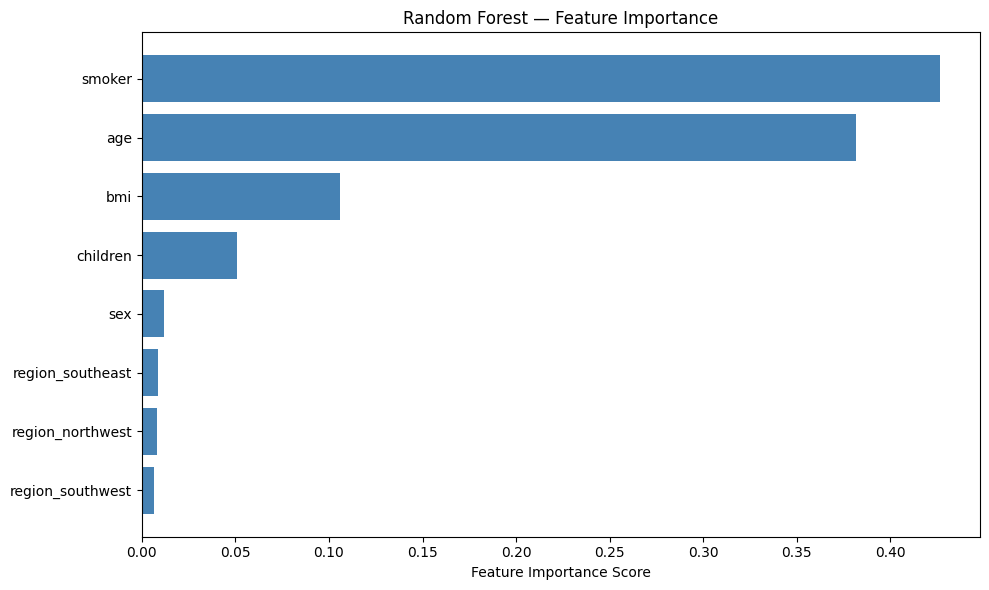

In [155]:
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

In [120]:
print(f"Smoker importance: {sorted_importances[0]:.4f}")
print(f"Everyone else combined: {sum(sorted_importances[1:]):.4f}")

Smoker importance: 0.4266
Everyone else combined: 0.5734


In [121]:
import joblib 
joblib.dump(rf,'insurance_model.pkl')

['insurance_model.pkl']

In [122]:
import os
print(os.path.exists('insurance_model.pkl'))  # Should print True
print(X.columns.tolist())  # Show me the feature order

True
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [123]:
print(df['smoker'].value_counts())
print(df['smoker'].unique())

smoker
0    1063
1     274
Name: count, dtype: int64
[1 0]
